# 04 — Regularization and the Bayesian View

**Covers concept IDs:** D1, D2, D3, D4.

## Learning outcomes
1. State the lasso objective and describe what changes as $\lambda$ grows.
2. Derive the lasso as the MAP estimator under a Laplace prior.
3. State the ridge objective and derive it as the MAP under a Gaussian prior.
4. Explain why features must be *standardized* before applying L1 / L2 penalties.
5. Explain the shrinkage-bias / selection trade-off between lasso and OLS (with forward stepwise as a hybrid).

## 1. Key formulas

### Lasso (L1)
$$\hat\beta_{\text{lasso}} = \arg\min_\beta \underbrace{\sum_i (y_i - x_i'\beta)^2}_{\text{RSS}} \;+\; \lambda \underbrace{\sum_j |\beta_j|}_{\|\beta\|_1}.$$

### Ridge (L2)
$$\hat\beta_{\text{ridge}} = \arg\min_\beta \sum_i (y_i - x_i'\beta)^2 + \lambda \sum_j \beta_j^2.$$

### Behaviour as $\lambda$ varies
| $\lambda$ | Lasso coefficients | Ridge coefficients |
|---|---|---|
| $0$ | OLS | OLS |
| small | most non-zero, slight shrinkage | all non-zero, slight shrinkage |
| moderate | many become exactly zero (selection) | all shrink toward zero, none exactly zero |
| $\to\infty$ | all zero | all zero |

### Bias–variance intuition
- $\lambda \uparrow$ ⇒ more bias, less variance — think "simpler model".
- $\lambda \downarrow$ ⇒ less bias, more variance — approaching OLS overfit.

### Overfitting signature
(from Module 3 lecture) training $R^2$ is a non-decreasing function of $\lambda\downarrow$, but test $R^2$ is typically hump-shaped — best at an interior $\lambda^\star$.

## 2. Derivation — lasso = MAP under Laplace prior

**Setup.** Linear model $y_i = x_i'\beta + \varepsilon_i$ with $\varepsilon_i\sim\mathcal N(0,\sigma^2)$, and a prior
$$p(\beta_j) = \frac{1}{2b}\exp\!\Big(-\frac{|\beta_j|}{b}\Big),\qquad \beta_1,\ldots,\beta_p \text{ iid.}$$

**Step 1 — likelihood.** Gaussian errors give
$$L(\beta) \propto \exp\!\Big(-\frac{1}{2\sigma^2}\sum_i (y_i - x_i'\beta)^2\Big).$$

**Step 2 — prior.** iid Laplace yields
$$p(\beta) = \prod_j \frac{1}{2b}e^{-|\beta_j|/b} = \frac{1}{(2b)^p}\exp\!\Big(-\frac{1}{b}\sum_j |\beta_j|\Big).$$

**Step 3 — posterior ∝ likelihood × prior.**
$$\log p(\beta\mid \text{data}) \;=\; -\frac{1}{2\sigma^2}\sum_i(y_i - x_i'\beta)^2 \;-\; \frac{1}{b}\sum_j|\beta_j| \;+\; \text{const.}$$

**Step 4 — multiply by $-2\sigma^2$ and drop constants.** The sign flips argmax to argmin:
$$\hat\beta_{\text{MAP}} = \arg\min_\beta \sum_i(y_i - x_i'\beta)^2 + \underbrace{\frac{2\sigma^2}{b}}_{\lambda}\sum_j|\beta_j|.$$

This is exactly the lasso with $\lambda = 2\sigma^2/b$. **Tighter prior** (small $b$, i.e., strong Bayesian belief that coefficients are near zero) = **more regularization** (large $\lambda$). $\boxed{\text{Lasso} = \text{MAP with Laplace prior.}}$

## 3. Derivation — ridge = MAP under Gaussian prior

Replace the Laplace prior with $\beta_j\stackrel{iid}{\sim}\mathcal N(0,\tau^2)$:
$$p(\beta) \propto \exp\!\Big(-\frac{1}{2\tau^2}\sum_j \beta_j^2\Big).$$

Repeat the same argument; the log-posterior is quadratic in $\beta$, and you recover the **ridge** objective with $\lambda_{\text{ridge}} = \sigma^2/\tau^2$.

Why lasso zeros out coefficients but ridge does not: the Laplace prior has a *cusp* at 0 (the $|\beta|$ term is non-differentiable), which makes 0 an attainable optimum; the Gaussian prior is smooth at 0, so the MAP is always interior.

## 4. Standardization — why it matters

The penalty $\lambda\|\beta\|_1$ treats every coefficient equally. If one feature is measured in dollars and another in thousands of dollars, the dollar feature will have coefficients ~1,000× larger, and the penalty will *preferentially shrink it* even though the feature is no more/less informative.

**Rule.** Centre and scale every numerical feature to unit variance before applying L1 / L2:
$$\tilde x_j = (x_j - \bar x_j) / \hat\sigma_{x_j}.$$

After standardization the penalty is **scale-invariant**, so the fitted weights reflect *signal strength*, not *units*. This was applied in Assignment 3 Q5 (`Normalize(sp500)`).

## 5. Shrinkage bias

Even for the *selected* features, the lasso gives biased (smaller-in-magnitude) coefficients compared to OLS on the same subset. That's why in Assignment 3 Q4 the forward-stepwise model on the SP500 beat lasso on the test set: stepwise uses **OLS coefficients** after selection, while lasso uses shrunken coefficients whose total weight sums to ~0.98 rather than 1.

A two-stage workaround sometimes used in practice:
1. Run lasso to select features (those with non-zero $\hat\beta$).
2. Refit OLS on that subset. Often called **relaxed lasso**.

## 6. Small code demo — lasso path

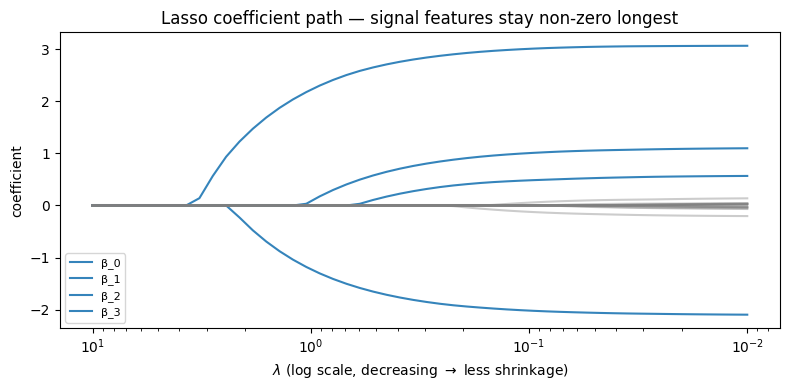

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path
from sklearn.preprocessing import StandardScaler

np.random.seed(1)
n, p = 200, 20
X = np.random.normal(size=(n, p))
X = StandardScaler().fit_transform(X)
true_beta = np.r_[[3, -2, 1, 0.5] + [0]*(p-4)]
y = X @ true_beta + np.random.normal(scale=1.0, size=n)

alphas, coefs, _ = lasso_path(X, y, alphas=np.logspace(-2, 1, 50))
plt.figure(figsize=(8, 4))
for j in range(p):
    plt.plot(alphas, coefs[j], label=f'β_{j}' if j<4 else None,
             color='C0' if true_beta[j]!=0 else 'grey', alpha=0.9 if true_beta[j]!=0 else 0.4)
plt.xscale('log')
plt.gca().invert_xaxis()           # so 'big λ' is on the right
plt.xlabel(r'$\lambda$ (log scale, decreasing $\to$ less shrinkage)')
plt.ylabel('coefficient')
plt.title('Lasso coefficient path — signal features stay non-zero longest')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

## 7. Practice problems

### 7.1 MC style
> What happens as $\lambda$ increases in lasso? (A) coefficients grow (B) more coefficients shrink to zero (C) variance increases (D) training error decreases.

**Answer.** **(B)** — heavier penalty forces more $\hat\beta_j$ exactly to 0. (C) is wrong — variance of predictions *decreases* with more shrinkage; (D) is wrong — training error *increases* as the model becomes more constrained.

### 7.2 Concept — standardization
> Why is standardization important before lasso?

**Answer.** The L1 penalty $\lambda\sum|\beta_j|$ is scale-dependent: features with large units will have naturally-smaller coefficients and be preferentially retained, while features with small units will be pushed to zero regardless of their signal. Standardizing every feature to mean 0 / variance 1 makes the penalty treat all features equally.

### 7.3 Full MAP derivation
> Show that the lasso is the MAP estimator under the model $y=X\beta+\varepsilon$, $\varepsilon_i\sim\mathcal N(0,\sigma^2)$, with an iid Laplace(0, b) prior on $\beta_j$.

**Answer.** See §2 above. Final result: $\hat\beta_{\text{MAP}} = \arg\min_\beta \text{RSS}+ (2\sigma^2/b)\|\beta\|_1$.

### 7.4 Compare lasso vs stepwise
> In Assignment 3, forward stepwise with 30 features achieved test RSS ≈ 2, while lasso with ~30 non-zero features achieved test RSS ≈ 140. Why?

**Answer.** Lasso shrinks selected coefficients toward zero, so its fitted portfolio under-tracks (sum of abs coefficients ≈ 0.98 < 1). Stepwise uses *unshrunken* OLS coefficients on the same number of features, giving an unbiased fit; with time-series prices where the test period has different levels, stepwise's level-matching helps while lasso's shrinkage hurts. The fix would be the "relaxed lasso": use lasso only for selection, then refit OLS.

### 7.5 Bias / variance
> As $\lambda$ goes from 0 to ∞, describe what happens to (a) bias of $\hat\beta$, (b) variance of $\hat\beta$, (c) training RSS, (d) test RSS.

**Answer.** (a) Bias grows (from 0 at OLS to maximum at $\hat\beta=0$). (b) Variance shrinks (from OLS variance to 0). (c) Training RSS grows. (d) Test RSS is typically U-shaped: overfits on the left, underfits on the right, minimized at some intermediate $\lambda^\star$.